# general libraries

In [2]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import multilabel_confusion_matrix
import numpy as np
import pandas as pd
import os
import json
import random
import argparse

In [3]:
import os
import json
import random 
import argparse


def read_json(path):
    with open(path, 'r') as file:
        data = json.load(file)
    return data

def write_json(data, path):
    if not os.path.exists(os.path.dirname(path)):
        os.makedirs(os.path.dirname(path))
    with open(path, 'w') as file:
        json.dump(data, file, indent=4)

In [4]:
def mean_undefined_relations(file_path):
    data = read_json(file_path)

    stats=[]
    for item in data:
        stats.append({
            'task_id': item['task_id'],
            'count_unique_hallucination': item['count_unique_hallucination'],
            'total_hallucination': len(item['hallucination'])
        })

    return pd.DataFrame(stats)


In [5]:
def all_unique_undefined(file_path):
    df = pd.read_json(file_path)
    unique_undefined = df['unique_hallucinated_relations']
    hallucination = []
    for i in range(len(unique_undefined)):
        hallucination.extend(list(unique_undefined[i]))
    return list(set(hallucination))

## TACRED

In [8]:
tacred_false={
    'baseline':'/Users/sefika/phd_projects/llm-catastrophic-re/results_all/last_results/tacred/baseline/baseline_false_pred.json',
    'mas':'/Users/sefika/phd_projects/llm-catastrophic-re/results_all/last_results/tacred/mas_correct_tacred/mas_false_pred.json',
    'ewc':'/Users/sefika/phd_projects/llm-catastrophic-re/results_all/last_results/tacred/ewc_corrected_tacred_100/elastic_weight_consolidation_false_pred.json',
    'si':'/Users/sefika/phd_projects/llm-catastrophic-re/results_all/last_results/tacred/si_tacred_flan_random/synaptic_intelligenece_false_pred.json',
}

In [9]:
base_results_df = mean_undefined_relations(tacred_false['baseline'])
mas_results_df = mean_undefined_relations(tacred_false['mas'])
si_results_df = mean_undefined_relations(tacred_false['si'])
ewc_results_df = mean_undefined_relations(tacred_false['ewc'])
tacred_results = {
'base_mean':base_results_df.groupby('task_id')['count_unique_hallucination'].mean().reset_index()['count_unique_hallucination'],
'base_std':base_results_df.groupby('task_id')['count_unique_hallucination'].std().reset_index()['count_unique_hallucination'],
'mas_mean':mas_results_df.groupby('task_id')['count_unique_hallucination'].mean().reset_index()['count_unique_hallucination'],
'mas_std':mas_results_df.groupby('task_id')['count_unique_hallucination'].std().reset_index()['count_unique_hallucination'],
'ewc_mean':ewc_results_df.groupby('task_id')['count_unique_hallucination'].mean().reset_index()['count_unique_hallucination'],
'ewc_std':ewc_results_df.groupby('task_id')['count_unique_hallucination'].std().reset_index()['count_unique_hallucination'],
'si_mean':si_results_df.groupby('task_id')['count_unique_hallucination'].mean().reset_index()['count_unique_hallucination'],
'si_std':si_results_df.groupby('task_id')['count_unique_hallucination'].std().reset_index()['count_unique_hallucination']
}


In [10]:
tacred_results_df = pd.DataFrame(tacred_results)
tacred_results_df.to_json('tacred.json')

In [11]:
import numpy as np

def mean_and_stderr(df):
    """
    Computes mean and standard error of 'count_unique_hallucination'
    per task_id for a given results dataframe.
    """
    grouped = df.groupby('task_id')['count_unique_hallucination']
    stats = grouped.agg(['mean', 'std', 'count']).reset_index()
    stats['stderr'] = stats['std'] / np.sqrt(stats['count'])
    return stats

base_stats = mean_and_stderr(base_results_df)
mas_stats  = mean_and_stderr(mas_results_df)
ewc_stats  = mean_and_stderr(ewc_results_df)
si_stats   = mean_and_stderr(si_results_df)

tacred_results = {
    'base_mean':   base_stats['mean'],
    'base_stderr': base_stats['stderr'],

    'mas_mean':    mas_stats['mean'],
    'mas_stderr':  mas_stats['stderr'],

    'ewc_mean':    ewc_stats['mean'],
    'ewc_stderr':  ewc_stats['stderr'],

    'si_mean':     si_stats['mean'],
    'si_stderr':   si_stats['stderr'],
}


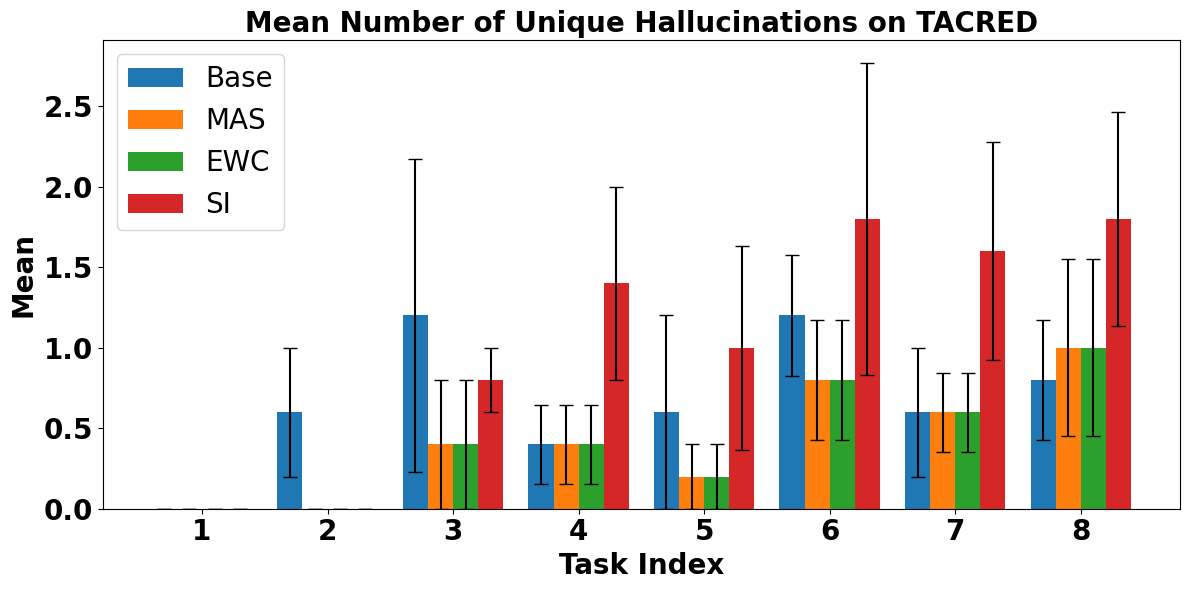

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def truncated_yerr(mean, stderr):
    """
    Build asymmetric error so bars don't go below 0.
    mean, stderr: pandas Series or numpy arrays of same length
    Returns array of shape (2, N) for matplotlib yerr.
    """
    lower = np.minimum(stderr, mean)   # don't let lower error exceed mean
    upper = stderr                     # upper error unchanged
    return np.vstack([lower, upper])

# Convert your tacred_results dict (with *_mean and *_stderr) to DataFrame
tacred_df = pd.DataFrame(tacred_results).astype(float)

# X axis labels (tasks 1..N, robust to #tasks)
num_tasks = len(tacred_df)
x = np.arange(1, num_tasks + 1)

plt.figure(figsize=(12, 6))

width = 0.2

plt.bar(
    x - 1.5*width,
    tacred_df["base_mean"],
    width,
    yerr=truncated_yerr(tacred_df["base_mean"].values,
                        tacred_df["base_stderr"].values),
    capsize=5,
    label="Base"
)

plt.bar(
    x - 0.5*width,
    tacred_df["mas_mean"],
    width,
    yerr=truncated_yerr(tacred_df["mas_mean"].values,
                        tacred_df["mas_stderr"].values),
    capsize=5,
    label="MAS"
)

plt.bar(
    x + 0.5*width,
    tacred_df["ewc_mean"],
    width,
    yerr=truncated_yerr(tacred_df["ewc_mean"].values,
                        tacred_df["ewc_stderr"].values),
    capsize=5,
    label="EWC"
)

plt.bar(
    x + 1.5*width,
    tacred_df["si_mean"],
    width,
    yerr=truncated_yerr(tacred_df["si_mean"].values,
                        tacred_df["si_stderr"].values),
    capsize=5,
    label="SI"
)

plt.xlabel("Task Index", fontsize=20, fontweight="bold")
plt.ylabel("Mean", fontsize=20, fontweight="bold")
plt.title("Mean Number of Unique Hallucinations on TACRED", fontsize=20, fontweight="bold")
plt.xticks(x, fontsize=20, fontweight="bold")
plt.yticks(fontsize=20, fontweight="bold")
plt.legend(fontsize=20)
plt.tight_layout()
plt.savefig("tacred_unique_hallucinations.png", dpi=300)
plt.show()


In [20]:
base_uniques = all_unique_undefined(tacred_false['baseline'])
mas_uniques = all_unique_undefined(tacred_false['mas'])
si_uniques = all_unique_undefined(tacred_false['si'])
ewc_uniques = all_unique_undefined(tacred_false['ewc'])
tacred_unique_hallucination_results = {
'base': base_uniques,
'mas': mas_uniques,
'si': si_uniques,
'ewc': ewc_uniques
}


In [21]:
write_json(tacred_unique_hallucination_results, './tacred_unique_hallucination_results.json')



In [40]:
base_results_df = mean_undefined_relations(tacred_false['baseline'])
mas_results_df = mean_undefined_relations(tacred_false['mas'])
si_results_df = mean_undefined_relations(tacred_false['si'])
ewc_results_df = mean_undefined_relations(tacred_false['ewc'])
tacred_results = {
'base_mean':base_results_df.groupby('task_id')['total_hallucination'].mean().reset_index()['total_hallucination'],
'base_std':base_results_df.groupby('task_id')['total_hallucination'].std().reset_index()['total_hallucination'],
'mas_mean':mas_results_df.groupby('task_id')['total_hallucination'].mean().reset_index()['total_hallucination'],
'mas_std':mas_results_df.groupby('task_id')['total_hallucination'].std().reset_index()['total_hallucination'],
'ewc_mean':ewc_results_df.groupby('task_id')['total_hallucination'].mean().reset_index()['total_hallucination'],
'ewc_std':ewc_results_df.groupby('task_id')['total_hallucination'].std().reset_index()['total_hallucination'],
'si_mean':si_results_df.groupby('task_id')['total_hallucination'].mean().reset_index()['total_hallucination'],
'si_std':si_results_df.groupby('task_id')['total_hallucination'].std().reset_index()['total_hallucination']
}


In [41]:
import numpy as np

def mean_and_stderr(df):
    """
    Computes mean and standard error of 'total_hallucination'
    per task_id for a given results dataframe.
    """
    grouped = df.groupby('task_id')['total_hallucination']
    stats = grouped.agg(['mean', 'std', 'count']).reset_index()
    stats['stderr'] = stats['std'] / np.sqrt(stats['count'])
    return stats

base_stats = mean_and_stderr(base_results_df)
mas_stats  = mean_and_stderr(mas_results_df)
ewc_stats  = mean_and_stderr(ewc_results_df)
si_stats   = mean_and_stderr(si_results_df)

tacred_results = {
    'base_mean':   base_stats['mean'],
    'base_stderr': base_stats['stderr'],

    'mas_mean':    mas_stats['mean'],
    'mas_stderr':  mas_stats['stderr'],

    'ewc_mean':    ewc_stats['mean'],
    'ewc_stderr':  ewc_stats['stderr'],

    'si_mean':     si_stats['mean'],
    'si_stderr':   si_stats['stderr'],
}


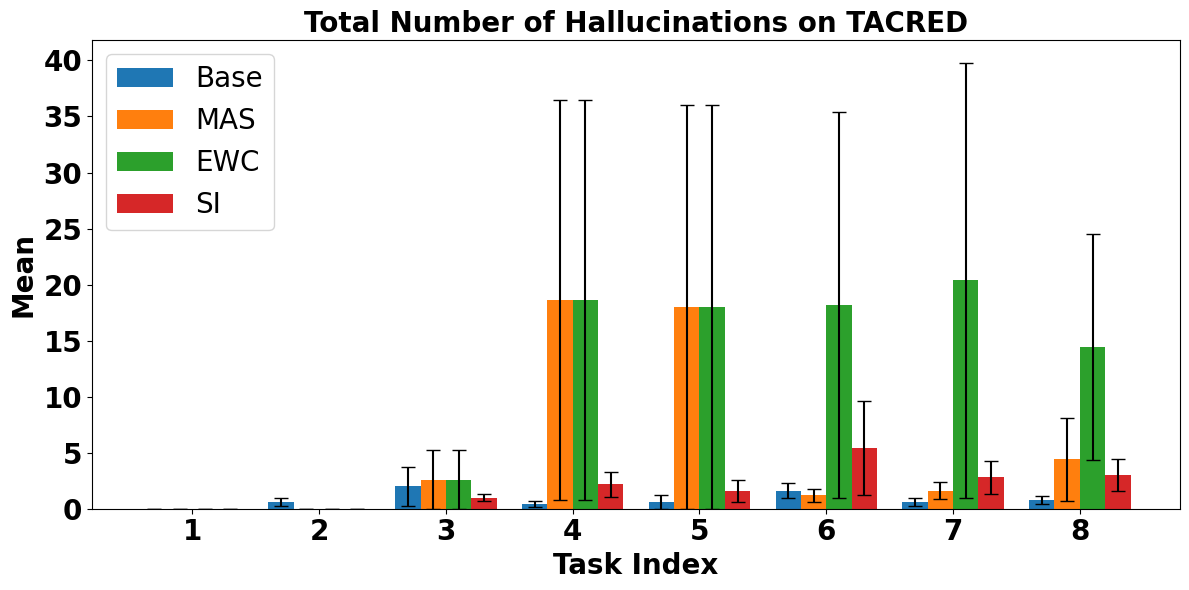

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def truncated_yerr(mean, stderr):
    """
    Build asymmetric error so bars don't go below 0.
    mean, stderr: pandas Series or numpy arrays of same length
    Returns array of shape (2, N) for matplotlib yerr.
    """
    lower = np.minimum(stderr, mean)   # don't let lower error exceed mean
    upper = stderr                     # upper error unchanged
    return np.vstack([lower, upper])

# Convert your tacred_results dict (with *_mean and *_stderr) to DataFrame
tacred_df = pd.DataFrame(tacred_results).astype(float)

# X axis labels (tasks 1..N, robust to #tasks)
num_tasks = len(tacred_df)
x = np.arange(1, num_tasks + 1)

plt.figure(figsize=(12, 6))

width = 0.2

plt.bar(
    x - 1.5*width,
    tacred_df["base_mean"],
    width,
    yerr=truncated_yerr(tacred_df["base_mean"].values,
                        tacred_df["base_stderr"].values),
    capsize=5,
    label="Base"
)

plt.bar(
    x - 0.5*width,
    tacred_df["mas_mean"],
    width,
    yerr=truncated_yerr(tacred_df["mas_mean"].values,
                        tacred_df["mas_stderr"].values),
    capsize=5,
    label="MAS"
)

plt.bar(
    x + 0.5*width,
    tacred_df["ewc_mean"],
    width,
    yerr=truncated_yerr(tacred_df["ewc_mean"].values,
                        tacred_df["ewc_stderr"].values),
    capsize=5,
    label="EWC"
)

plt.bar(
    x + 1.5*width,
    tacred_df["si_mean"],
    width,
    yerr=truncated_yerr(tacred_df["si_mean"].values,
                        tacred_df["si_stderr"].values),
    capsize=5,
    label="SI"
)

plt.xlabel("Task Index", fontsize=20, fontweight="bold")
plt.ylabel("Mean", fontsize=20, fontweight="bold")
plt.title("Total Number of Hallucinations on TACRED", fontsize=20, fontweight="bold")
plt.xticks(x, fontsize=20, fontweight="bold")
plt.yticks(fontsize=20, fontweight="bold")
plt.legend(fontsize=20)
plt.tight_layout()
plt.savefig("tacred_total_hallucinations.png", dpi=300)
plt.show()


## FewRel

In [28]:
fewrel_false = {
    'baseline':'/Users/sefika/phd_projects/llm-catastrophic-re/results_all/fewrel_corrected_results/tmlr/baseline/baseline_false_pred.json',
    'mas':'/Users/sefika/phd_projects/llm-catastrophic-re/results_all/fewrel_corrected_results/tmlr/mas/mas_false_pred.json',
    'ewc':'/Users/sefika/phd_projects/llm-catastrophic-re/results_all/fewrel_corrected_results/tmlr/ewc/elastic_weight_consolidation_false_pred.json',
    'si':'/Users/sefika/phd_projects/llm-catastrophic-re/results_all/fewrel_corrected_results/tmlr/si/synaptic_intelligenece_false_pred.json'
}

In [29]:
base_results_df = mean_undefined_relations(fewrel_false['baseline'])
mas_results_df = mean_undefined_relations(fewrel_false['mas'])
si_results_df = mean_undefined_relations(fewrel_false['si'])
ewc_results_df = mean_undefined_relations(fewrel_false['ewc'])
fewrel_results = {
'base_mean':base_results_df.groupby('task_id')['count_unique_hallucination'].mean().reset_index()['count_unique_hallucination'],
'base_std':base_results_df.groupby('task_id')['count_unique_hallucination'].std().reset_index()['count_unique_hallucination'],
'mas_mean':mas_results_df.groupby('task_id')['count_unique_hallucination'].mean().reset_index()['count_unique_hallucination'],
'mas_std':mas_results_df.groupby('task_id')['count_unique_hallucination'].std().reset_index()['count_unique_hallucination'],
'ewc_mean':ewc_results_df.groupby('task_id')['count_unique_hallucination'].mean().reset_index()['count_unique_hallucination'],
'ewc_std':ewc_results_df.groupby('task_id')['count_unique_hallucination'].std().reset_index()['count_unique_hallucination'],
'si_mean':si_results_df.groupby('task_id')['count_unique_hallucination'].mean().reset_index()['count_unique_hallucination'],
'si_std':si_results_df.groupby('task_id')['count_unique_hallucination'].std().reset_index()['count_unique_hallucination']
}


In [30]:
fewrel_results = []

In [31]:
import numpy as np

def mean_and_stderr(df):
    """
    Computes mean and standard error of 'count_unique_hallucination'
    per task_id for a given results dataframe.
    """
    grouped = df.groupby('task_id')['count_unique_hallucination']
    stats = grouped.agg(['mean', 'std', 'count']).reset_index()
    stats['stderr'] = stats['std'] / np.sqrt(stats['count'])
    return stats

base_stats = mean_and_stderr(base_results_df)
mas_stats  = mean_and_stderr(mas_results_df)
ewc_stats  = mean_and_stderr(ewc_results_df)
si_stats   = mean_and_stderr(si_results_df)

fewrel_results = {
    'base_mean':   base_stats['mean'],
    'base_stderr': base_stats['stderr'],

    'mas_mean':    mas_stats['mean'],
    'mas_stderr':  mas_stats['stderr'],

    'ewc_mean':    ewc_stats['mean'],
    'ewc_stderr':  ewc_stats['stderr'],

    'si_mean':     si_stats['mean'],
    'si_stderr':   si_stats['stderr'],
}


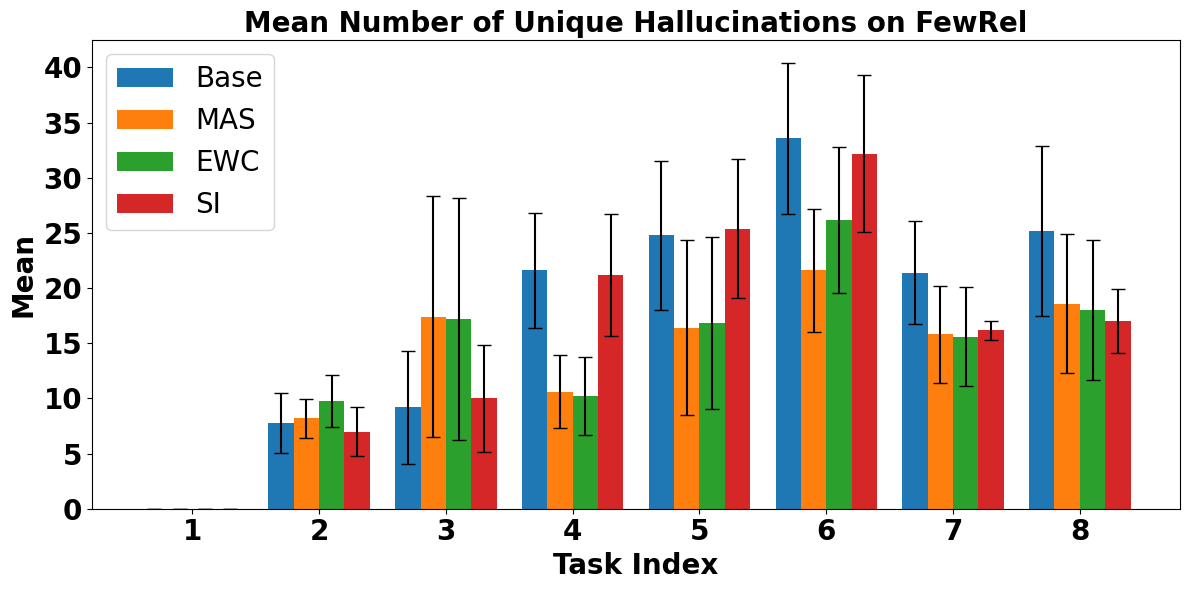

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def truncated_yerr(mean, stderr):
    """
    Build asymmetric error so bars don't go below 0.
    mean, stderr: pandas Series or numpy arrays of same length
    Returns array of shape (2, N) for matplotlib yerr.
    """
    lower = np.minimum(stderr, mean)   # don't let lower error exceed mean
    upper = stderr                     # upper error unchanged
    return np.vstack([lower, upper])

# Convert your tacred_results dict (with *_mean and *_stderr) to DataFrame
fewrel_df = pd.DataFrame(fewrel_results).astype(float)

# X axis labels (tasks 1..N, robust to #tasks)
num_tasks = len(fewrel_df)
x = np.arange(1, num_tasks + 1)

plt.figure(figsize=(12, 6))

width = 0.2

plt.bar(
    x - 1.5*width,
    fewrel_df["base_mean"],
    width,
    yerr=truncated_yerr(fewrel_df["base_mean"].values,
                        fewrel_df["base_stderr"].values),
    capsize=5,
    label="Base"
)

plt.bar(
    x - 0.5*width,
    fewrel_df["mas_mean"],
    width,
    yerr=truncated_yerr(fewrel_df["mas_mean"].values,
                        fewrel_df["mas_stderr"].values),
    capsize=5,
    label="MAS"
)

plt.bar(
    x + 0.5*width,
    fewrel_df["ewc_mean"],
    width,
    yerr=truncated_yerr(fewrel_df["ewc_mean"].values,
                        fewrel_df["ewc_stderr"].values),
    capsize=5,
    label="EWC"
)

plt.bar(
    x + 1.5*width,
    fewrel_df["si_mean"],
    width,
    yerr=truncated_yerr(fewrel_df["si_mean"].values,
                        fewrel_df["si_stderr"].values),
    capsize=5,
    label="SI"
)

plt.xlabel("Task Index", fontsize=20, fontweight="bold")
plt.ylabel("Mean", fontsize=20, fontweight="bold")
plt.title("Mean Number of Unique Hallucinations on FewRel", fontsize=20, fontweight="bold")
plt.xticks(x, fontsize=20, fontweight="bold")
plt.yticks(fontsize=20, fontweight="bold")
plt.legend(fontsize=20)
plt.tight_layout()
plt.savefig("fewrel_unique_hallucinations.png", dpi=300)
plt.show()


In [36]:
base_results_df = mean_undefined_relations(fewrel_false['baseline'])
mas_results_df = mean_undefined_relations(fewrel_false['mas'])
si_results_df = mean_undefined_relations(fewrel_false['si'])
ewc_results_df = mean_undefined_relations(fewrel_false['ewc'])
fewrel_results = {
'base_mean':base_results_df.groupby('task_id')['total_hallucination'].mean().reset_index()['total_hallucination'],
'base_std':base_results_df.groupby('task_id')['total_hallucination'].std().reset_index()['total_hallucination'],
'mas_mean':mas_results_df.groupby('task_id')['total_hallucination'].mean().reset_index()['total_hallucination'],
'mas_std':mas_results_df.groupby('task_id')['total_hallucination'].std().reset_index()['total_hallucination'],
'ewc_mean':ewc_results_df.groupby('task_id')['total_hallucination'].mean().reset_index()['total_hallucination'],
'ewc_std':ewc_results_df.groupby('task_id')['total_hallucination'].std().reset_index()['total_hallucination'],
'si_mean':si_results_df.groupby('task_id')['total_hallucination'].mean().reset_index()['total_hallucination'],
'si_std':si_results_df.groupby('task_id')['total_hallucination'].std().reset_index()['total_hallucination']
}

In [37]:
import numpy as np

def mean_and_stderr(df):
    """
    Computes mean and standard error of 'total_hallucination'
    per task_id for a given results dataframe.
    """
    grouped = df.groupby('task_id')['total_hallucination']
    stats = grouped.agg(['mean', 'std', 'count']).reset_index()
    stats['stderr'] = stats['std'] / np.sqrt(stats['count'])
    return stats

base_stats = mean_and_stderr(base_results_df)
mas_stats  = mean_and_stderr(mas_results_df)
ewc_stats  = mean_and_stderr(ewc_results_df)
si_stats   = mean_and_stderr(si_results_df)

fewrel_results = {
    'base_mean':   base_stats['mean'],
    'base_stderr': base_stats['stderr'],

    'mas_mean':    mas_stats['mean'],
    'mas_stderr':  mas_stats['stderr'],

    'ewc_mean':    ewc_stats['mean'],
    'ewc_stderr':  ewc_stats['stderr'],

    'si_mean':     si_stats['mean'],
    'si_stderr':   si_stats['stderr'],
}


In [38]:
fewrel_results_df = pd.DataFrame(fewrel_results)
fewrel_results_df.to_json('total_fewrel.json')

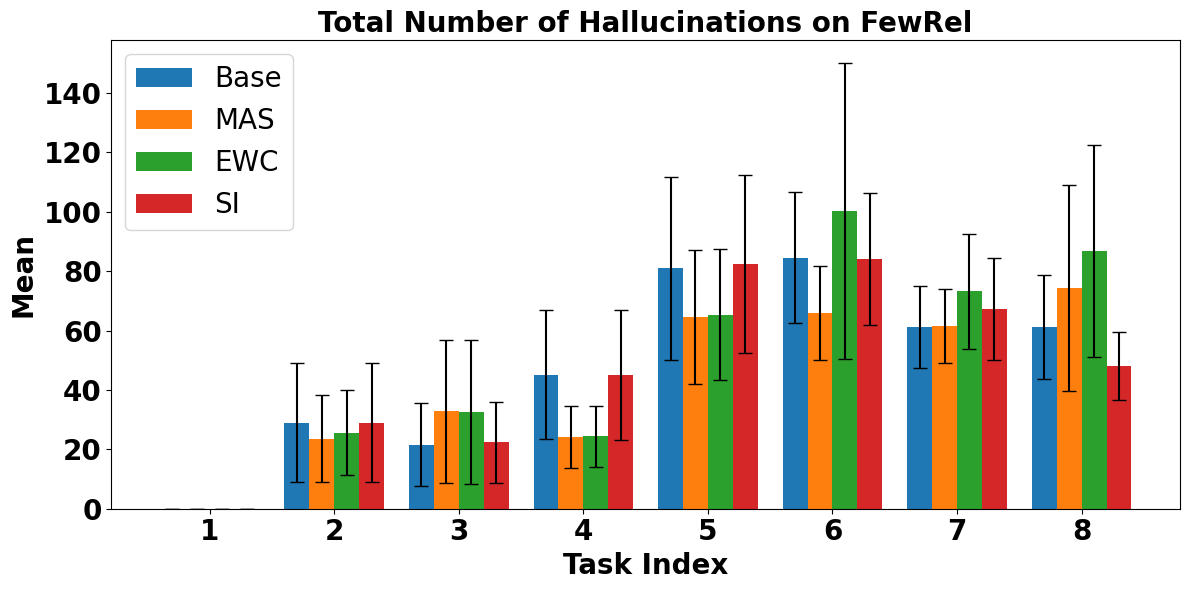

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def truncated_yerr(mean, stderr):
    """
    Build asymmetric error so bars don't go below 0.
    mean, stderr: pandas Series or numpy arrays of same length
    Returns array of shape (2, N) for matplotlib yerr.
    """
    lower = np.minimum(stderr, mean)   # don't let lower error exceed mean
    upper = stderr                     # upper error unchanged
    return np.vstack([lower, upper])

# Convert your tacred_results dict (with *_mean and *_stderr) to DataFrame
fewrel_df = pd.DataFrame(fewrel_results).astype(float)

# X axis labels (tasks 1..N, robust to #tasks)
num_tasks = len(fewrel_df)
x = np.arange(1, num_tasks + 1)

plt.figure(figsize=(12, 6))

width = 0.2

plt.bar(
    x - 1.5*width,
    fewrel_df["base_mean"],
    width,
    yerr=truncated_yerr(fewrel_df["base_mean"].values,
                        fewrel_df["base_stderr"].values),
    capsize=5,
    label="Base"
)

plt.bar(
    x - 0.5*width,
    fewrel_df["mas_mean"],
    width,
    yerr=truncated_yerr(fewrel_df["mas_mean"].values,
                        fewrel_df["mas_stderr"].values),
    capsize=5,
    label="MAS"
)

plt.bar(
    x + 0.5*width,
    fewrel_df["ewc_mean"],
    width,
    yerr=truncated_yerr(fewrel_df["ewc_mean"].values,
                        fewrel_df["ewc_stderr"].values),
    capsize=5,
    label="EWC"
)

plt.bar(
    x + 1.5*width,
    fewrel_df["si_mean"],
    width,
    yerr=truncated_yerr(fewrel_df["si_mean"].values,
                        fewrel_df["si_stderr"].values),
    capsize=5,
    label="SI"
)

plt.xlabel("Task Index", fontsize=20, fontweight="bold")
plt.ylabel("Mean", fontsize=20, fontweight="bold")
plt.title("Total Number of Hallucinations on FewRel", fontsize=20, fontweight="bold")
plt.xticks(x, fontsize=20, fontweight="bold")
plt.yticks(fontsize=20, fontweight="bold")
plt.legend(fontsize=20)
plt.tight_layout()
plt.savefig("fewrel_total_hallucinations.png", dpi=300)
plt.show()


In [82]:
base_uniques = all_unique_undefined(fewrel_false['baseline'])
mas_uniques = all_unique_undefined(fewrel_false['mas'])
si_uniques = all_unique_undefined(fewrel_false['si'])
ewc_uniques = all_unique_undefined(fewrel_false['ewc'])
fewrel_unique_hallucination_results = {
'base': base_uniques,
'mas': mas_uniques,
'si': si_uniques,
'ewc': ewc_uniques
}


In [83]:
write_json(fewrel_unique_hallucination_results, './fewrel_unique_hallucination_results.json')